In [1]:
# Imports, Data Prep & Feature Encoding
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

# Load dataset
df = pd.read_csv('churn-bigml-80.csv')

# Encode binary categories
df['International plan'] = df['International plan'].map({'Yes': 1, 'No': 0})
df['Voice mail plan'] = df['Voice mail plan'].map({'Yes': 1, 'No': 0})
df['Churn'] = df['Churn'].astype(int)

# Select predictive features (dropping high-cardinality State/Area code)
features = [
    'Account length', 'International plan', 'Voice mail plan', 'Number vmail messages',
    'Total day minutes', 'Total day calls', 'Total day charge',
    'Total eve minutes', 'Total eve calls', 'Total eve charge',
    'Total night minutes', 'Total night calls', 'Total night charge',
    'Total intl minutes', 'Total intl calls', 'Total intl charge',
    'Customer service calls'
]

X = df[features]
y = df['Churn']

# 80/20 Stratified Split to preserve churn proportion
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Level 3 Data Ready! Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Level 3 Data Ready! Training samples: 2132, Test samples: 534


Task 1 — Train Random Forest Classifier & Classification Report

In [2]:
# CELL 2: Train Random Forest & Generate Metrics
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Predictions & Probabilities
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Model Performance Report
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Stayed (0)', 'Churned (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  Stayed (0)       0.96      0.98      0.97       456
 Churned (1)       0.88      0.76      0.81        78

    accuracy                           0.95       534
   macro avg       0.92      0.87      0.89       534
weighted avg       0.95      0.95      0.95       534

ROC-AUC Score: 0.8974


Task 2

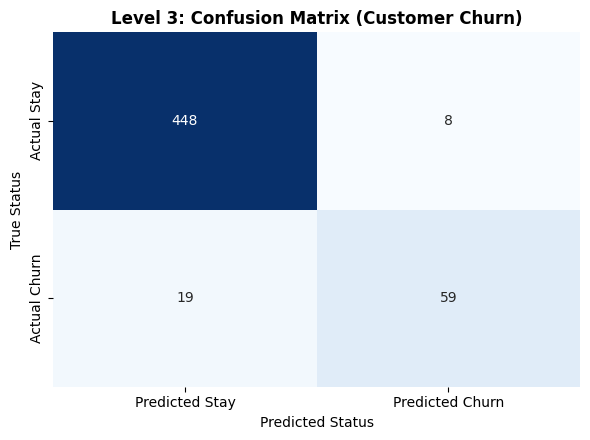

In [3]:
# Visual Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Stay', 'Predicted Churn'],
            yticklabels=['Actual Stay', 'Actual Churn'])
plt.title('Level 3: Confusion Matrix (Customer Churn)', fontweight='bold')
plt.ylabel('True Status')
plt.xlabel('Predicted Status')
plt.tight_layout()
plt.show()

C:\Users\abdul\AppData\Local\Temp\ipykernel_20724\530322534.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(8), x='Importance', y='Feature', palette='viridis')


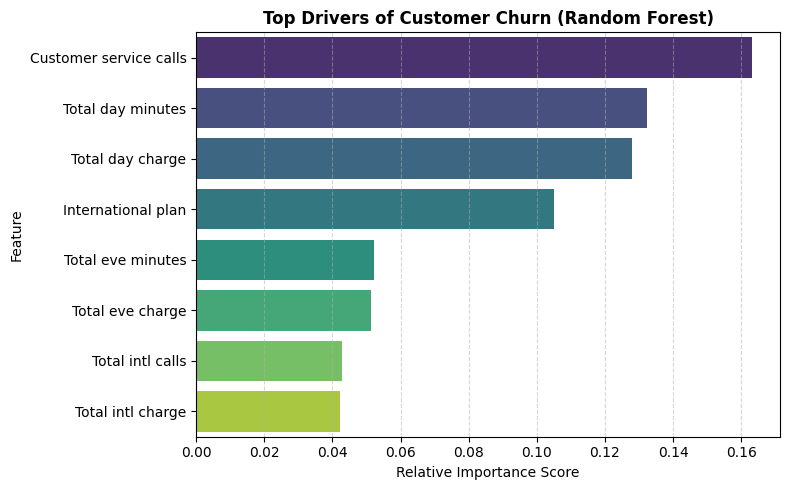

Top 5 Churn Factors:
               Feature  Importance
Customer service calls    0.163239
     Total day minutes    0.132218
      Total day charge    0.127860
    International plan    0.105158
     Total eve minutes    0.052340


In [4]:
# Feature Importance Ranking
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df.head(8), x='Importance', y='Feature', palette='viridis')
plt.title('Top Drivers of Customer Churn (Random Forest)', fontweight='bold')
plt.xlabel('Relative Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Top 5 Churn Factors:")
print(importance_df.head(5).to_string(index=False))